In [89]:
import pandas as pd

Imported the pandas library 

In [ ]:
df = pd.read_csv("srccd "Saas Churn Data"
git init
cd "Saas Churn Data"
git init
/saas_churn_data.csv")


print("\nData types:\n")
print(df.dtypes)

FileNotFoundError: [Errno 2] No such file or directory: 'data/saas_churn_data.csv'

After viewing the shape and overview of the dataset, i proceed to check for null values

In [ ]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)

null_summary = pd.concat([null_counts, null_pct], axis=1)
null_summary.columns = ["null_count", "null_percentage"]

print(null_summary.sort_values("null_count", ascending=False))


                         null_count  null_percentage
subscription_end_date           169             84.5
retention_rate_12m              108             54.0
retention_rate_6m                52             26.0
account_manager                  51             25.5
last_success_touch_date          17              8.5
customer_id                       0              0.0
customer_name                     0              0.0
subscription_status               0              0.0
industry                          0              0.0
subscription_start_date           0              0.0
user_count                        0              0.0
monthly_fee                       0              0.0
plan_type                         0              0.0
last_login_date                   0              0.0
feature_usage_score               0              0.0
monthly_active_users              0              0.0
churn_risk_score                  0              0.0
notes                             0           

In [ ]:
df_raw = df.copy()


Just applying date and time format to necessary columns and outputs

In [ ]:
date_cols = [
    "subscription_start_date",
    "subscription_end_date",
    "last_login_date",
    "last_success_touch_date"
]

df[date_cols] = df[date_cols].apply(pd.to_datetime, errors="coerce")


df[date_cols].dtypes


subscription_start_date    datetime64[ns]
subscription_end_date      datetime64[ns]
last_login_date            datetime64[ns]
last_success_touch_date    datetime64[ns]
dtype: object

In [ ]:
today = pd.Timestamp.today().normalize()
today


Timestamp('2026-01-09 00:00:00')

In [ ]:
df["tenure_months"] = (
    (df["subscription_end_date"].fillna(today) - df["subscription_start_date"])
    .dt.days / 30.44
)

df["tenure_months"].describe()


count    200.000000
mean      30.773325
std       11.918619
min        5.978975
25%       21.936597
50%       30.223390
75%       40.629106
max       61.892247
Name: tenure_months, dtype: float64

Checking for negative tenure

In [ ]:
df[df["tenure_months"] < 0]


,customer_id,customer_name,industry,account_manager,subscription_start_date,subscription_end_date,subscription_status,plan_type,monthly_fee,user_count,last_login_date,monthly_active_users,feature_usage_score,retention_rate_6m,retention_rate_12m,churn_risk_score,last_success_touch_date,notes,tenure_months


Query to get the recent login of users

In [ ]:
df["days_since_last_login"] = (today - df["last_login_date"]).dt.days

df["days_since_last_login"].describe()


count     200.000000
mean      615.975000
std       120.795872
min       574.000000
25%       584.000000
50%       589.000000
75%       600.250000
max      1403.000000
Name: days_since_last_login, dtype: float64

Looking for the monthly active users ratio

In [ ]:
df["mau_ratio"] = df["monthly_active_users"] / df["user_count"]

df["mau_ratio"].describe()


count    200.000000
mean       0.700347
std        0.340990
min        0.000000
25%        0.577068
50%        0.876524
75%        0.942580
max        1.000000
Name: mau_ratio, dtype: float64

In [ ]:
df[df["mau_ratio"] > 1]


,customer_id,customer_name,industry,account_manager,subscription_start_date,subscription_end_date,subscription_status,plan_type,monthly_fee,user_count,...,monthly_active_users,feature_usage_score,retention_rate_6m,retention_rate_12m,churn_risk_score,last_success_touch_date,notes,tenure_months,days_since_last_login,mau_ratio


In [ ]:
df_features = df.copy()


Since the activity levels vary so much, the risk of leaving isn't the same for everyone. To manage this effectively, i had to sort them into different groups

In [ ]:
df[["tenure_months", "days_since_last_login", "mau_ratio", "churn_risk_score"]].describe()


,tenure_months,days_since_last_login,mau_ratio,churn_risk_score
count,200.000000,200.000000,200.000000,200.000000
mean,31.224667,615.975000,0.700347,0.388300
std,12.093425,120.795872,0.340990,0.308876
min,6.066667,574.000000,0.000000,0.010000
25%,22.258333,584.000000,0.577068,0.130000
50%,30.666667,589.000000,0.876524,0.315000
75%,41.225000,600.250000,0.942580,0.552500
max,62.800000,1403.000000,1.000000,1.000000


sorted customers into groups low medium and high risk chance of quitting

In [ ]:
df["churn_risk_segment"] = pd.qcut(
    df["churn_risk_score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

df["churn_risk_segment"].value_counts()


churn_risk_segment
Low Risk       67
Medium Risk    67
High Risk      66
Name: count, dtype: int64

I've split the customers to determine a real pattern that shows the risk of leaving

In [ ]:
df.groupby("plan_type")["churn_risk_score"].mean().sort_values(ascending=False)


plan_type
Basic         0.670862
Pro           0.363882
Enterprise    0.137193
Name: churn_risk_score, dtype: float64

In [ ]:
df.groupby("plan_type")[["mau_ratio", "feature_usage_score"]].mean().round(2)


,mau_ratio,feature_usage_score
plan_type,,
Basic,0.43,18.68
Enterprise,0.89,85.00
Pro,0.76,62.70


In [ ]:
df.groupby(
    "churn_risk_segment",
    observed=True
)[["tenure_months", "mau_ratio", "feature_usage_score"]].mean().round(2)


,tenure_months,mau_ratio,feature_usage_score
churn_risk_segment,,,
Low Risk,43.04,0.94,90.41
Medium Risk,30.83,0.84,63.49
High Risk,19.62,0.32,14.34


In [ ]:
df[[
    "churn_risk_score",
    "mau_ratio",
    "feature_usage_score",
    "tenure_months",
    "days_since_last_login"
]].corr().round(2)


,churn_risk_score,mau_ratio,feature_usage_score,tenure_months,days_since_last_login
churn_risk_score,1.00,-0.92,-0.96,-0.82,0.45
mau_ratio,-0.92,1.00,0.87,0.74,-0.48
feature_usage_score,-0.96,0.87,1.00,0.81,-0.38
tenure_months,-0.82,0.74,0.81,1.00,-0.24
days_since_last_login,0.45,-0.48,-0.38,-0.24,1.00


### Summary
Feature usage is the strongest churn (-0.96) followed by Monthly active users (-0.92) and the Tenure (-0.82)


- Correlation does not necessarily determine causation.
- The Dataset is synthetic and too clean so it cannot be as unpredictable unlike real world data which would be more messy.


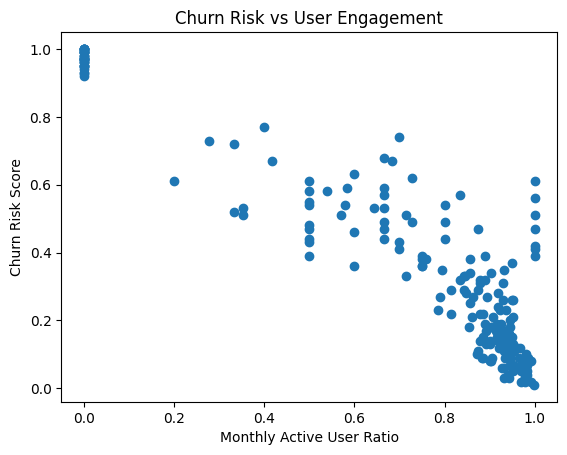

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["mau_ratio"], df["churn_risk_score"])
plt.xlabel("Monthly Active User Ratio")
plt.ylabel("Churn Risk Score")
plt.title("Churn Risk vs User Engagement")
plt.show()


clear downward trend

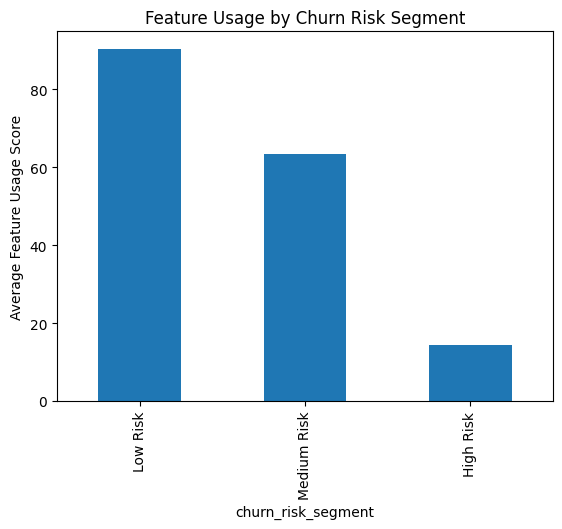

In [ ]:
segment_usage = (
    df.groupby("churn_risk_segment", observed=True)["feature_usage_score"]
      .mean()
)

plt.figure()
segment_usage.plot(kind="bar")
plt.ylabel("Average Feature Usage Score")
plt.title("Feature Usage by Churn Risk Segment")
plt.show()


Feature adoption decreases as churn risk increases

<Figure size 640x480 with 0 Axes>

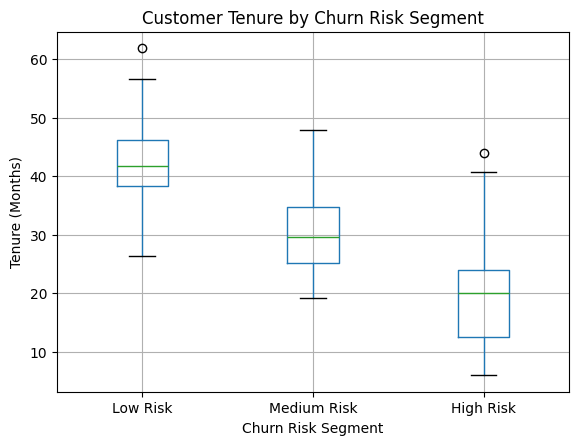

In [ ]:
plt.figure()
df.boxplot(column="tenure_months", by="churn_risk_segment")
plt.xlabel("Churn Risk Segment")
plt.ylabel("Tenure (Months)")
plt.title("Customer Tenure by Churn Risk Segment")
plt.suptitle("")  # removes default pandas title
plt.show()


<Figure size 640x480 with 0 Axes>

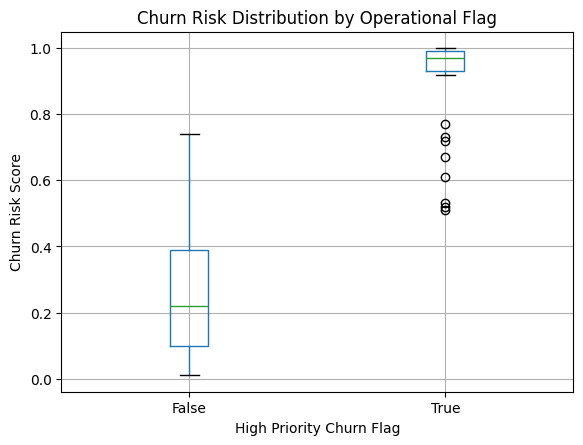

In [94]:
plt.figure()
df.boxplot(column="churn_risk_score", by="high_priority_churn_flag")
plt.xlabel("High Priority Churn Flag")
plt.ylabel("Churn Risk Score")
plt.title("Churn Risk Distribution by Operational Flag")
plt.suptitle("")
plt.show()



In [91]:
df["high_priority_churn_flag"] = (
    (df["mau_ratio"] < 0.5) &
    (df["feature_usage_score"] < 30)
)


In [ ]:
df["high_priority_churn_flag"].value_counts()


high_priority_churn_flag
False    161
True      39
Name: count, dtype: int64

In [ ]:
df.groupby("high_priority_churn_flag")["churn_risk_score"].mean().round(2)


high_priority_churn_flag
False    0.26
True     0.90
Name: churn_risk_score, dtype: float64

In [92]:
pd.crosstab(
    df["high_priority_churn_flag"],
    df["churn_risk_segment"],
    normalize="index"
).round(2)


churn_risk_segment,Low Risk,Medium Risk,High Risk
high_priority_churn_flag,,,
False,0.42,0.42,0.17
True,0.00,0.00,1.00
